# Config A — Tabular Reinforcement Learning

Combined notebook covering Dynamic Programming, Q-Learning, and SARSA on the discrete ICU-Sepsis-v2 environment (716 states, 25 actions). All hyperparameter searches are parallelised with joblib and cached to `results/config_a/` so the notebook can be re-run without retraining.

In [1]:
import sys, os, json, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from joblib import Parallel, delayed

# Make project root importable
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Run from project root so relative paths (results/, plots/) resolve correctly
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir(project_root)

from envs.env_setup import make_sepsis_env, N_STATES, N_ACTIONS, GAMMA
from utils.evaluation import eval_agent, print_results
from agents.config_a.q_learning import QLearningAgent, QLearningConfig
from agents.config_a.sarsa import SARSAAgent, SARSAConfig
from utils.search import run_ql_trial, run_sarsa_trial

SEED      = 42
N_EVAL    = 1_000   # fixed eval budget for all reported results
N_JOBS    = 4       # parallel workers — reduce to 2 on slower machines

RESULTS_DIR = 'results/config_a'
SEARCH_DIR  = 'results/config_a/search'
os.makedirs(SEARCH_DIR, exist_ok=True)

print(f"State space : {N_STATES} states")
print(f"Action space: {N_ACTIONS} actions")
print(f"Gamma       : {GAMMA}")
print(f"Project root: {project_root}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


State space : 716 states
Action space: 25 actions
Gamma       : 1.0
Project root: /Users/mehmet/src/Reinforcement_Learning_Project


## §1 Random Baseline

A uniformly random policy provides the lower bound against which all learned policies are measured.

In [2]:
np.random.seed(SEED)
random_policy = lambda obs: int(np.random.randint(N_ACTIONS))
random_results = eval_agent(random_policy, make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
print_results("Random Baseline", random_results)


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline ===
  Mean return  : 0.6395 ± 0.4445
  Survival rate: 74.3%
  Mean ep len  : 10.3


## §2 Dynamic Programming

Dynamic Programming (DP) is a **model-based** method: it computes the optimal policy directly from the known transition matrix P(s'|s,a) and reward matrix R(s,a,s'), without any environment interaction during training. This is feasible in Config A because the full MDP is accessible.

Two algorithms are compared:
- **Policy Iteration** — alternates between full policy evaluation (Bellman expectation) and greedy policy improvement until the policy stabilises.
- **Value Iteration** — combines both steps into a single Bellman optimality sweep, requiring more iterations but simpler implementation.

Both use convergence threshold ε = 1×10⁻⁶ and γ = 1.0 (no temporal discounting, per the ICU-Sepsis paper convention).

In [3]:
# ── DP algorithm implementations (from 01_config_a_dp.ipynb) ─────────────────

def compute_expected_reward(P, R):
    """R(s,a,s') → R_expected(s,a) by summing over next states."""
    return np.sum(P * R, axis=2)

def compute_value_function(policy, P, R_expected, gamma=1.0, tol=1e-6, max_iter=10_000):
    """Iterative policy evaluation: V(s) = Σ_s' P(s'|s,π(s))[R(s,π(s)) + γV(s')]"""
    n_states = P.shape[0]
    V = np.zeros(n_states)
    for _ in range(max_iter):
        V_new = np.array([
            np.sum(P[s, policy[s]] * (R_expected[s, policy[s]] + gamma * V))
            for s in range(n_states)
        ])
        if np.max(np.abs(V_new - V)) < tol:
            break
        V = V_new
    return V

def extract_policy(V, P, R_expected, gamma=1.0):
    """Greedy policy improvement: π(s) = argmax_a Σ_s' P(s'|s,a)[R(s,a) + γV(s')]"""
    n_states, n_actions = R_expected.shape
    Q = np.array([
        [np.sum(P[s, a] * (R_expected[s, a] + gamma * V)) for a in range(n_actions)]
        for s in range(n_states)
    ])
    return np.argmax(Q, axis=1)

def policy_iteration(P, R, gamma=1.0, tol=1e-6, max_iter=1_000):
    """Policy Iteration: alternate evaluation and improvement until convergence."""
    R_exp = compute_expected_reward(P, R)
    n_states = P.shape[0]
    policy = np.zeros(n_states, dtype=int)
    deltas = []
    for i in range(max_iter):
        V = compute_value_function(policy, P, R_exp, gamma, tol)
        new_policy = extract_policy(V, P, R_exp, gamma)
        delta = np.sum(new_policy != policy)
        deltas.append(delta)
        if np.array_equal(new_policy, policy):
            print(f"Policy Iteration converged after {i+1} iteration(s).")
            break
        policy = new_policy
    return policy, V, deltas

def value_iteration(P, R, gamma=1.0, tol=1e-6, max_iter=10_000):
    """Value Iteration: Bellman optimality sweeps until convergence."""
    R_exp = compute_expected_reward(P, R)
    n_states, n_actions = R_exp.shape
    V = np.zeros(n_states)
    deltas = []
    for i in range(max_iter):
        Q = np.array([
            [np.sum(P[s, a] * (R_exp[s, a] + gamma * V)) for a in range(n_actions)]
            for s in range(n_states)
        ])
        V_new = np.max(Q, axis=1)
        delta = np.max(np.abs(V_new - V))
        deltas.append(delta)
        V = V_new
        if delta < tol:
            print(f"Value Iteration converged after {i+1} iteration(s).")
            break
    policy = np.argmax(Q, axis=1)
    return policy, V, deltas

def get_dp_policy(policy_array):
    return lambda obs: int(policy_array[obs])

# Extract MDP matrices
_env = make_sepsis_env(verbose=False)
_raw = _env.unwrapped
P = _raw._tx_mat          # shape (S, A, S)
R = _raw._r_mat           # shape (S, A, S)
print(f"P shape: {P.shape},  R shape: {R.shape}")


P shape: (716, 25, 716),  R shape: (716, 25, 716)


### §2.1 Gamma Sensitivity

In [4]:
# Grid search over gamma — cached to CSV
DP_GAMMA_CSV = f'{RESULTS_DIR}/dp_gamma_results.csv'

if os.path.exists(DP_GAMMA_CSV):
    dp_gamma_df = pd.read_csv(DP_GAMMA_CSV)
    print("Loaded DP gamma results from cache.")
else:
    gamma_grid = [0.90, 0.95, 0.99, 1.00]
    rows = []
    for g in gamma_grid:
        pi_pol, _, _ = policy_iteration(P, R, gamma=g)
        vi_pol, _, _ = value_iteration(P, R, gamma=g)
        pi_res = eval_agent(get_dp_policy(pi_pol), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
        vi_res = eval_agent(get_dp_policy(vi_pol), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
        rows.append({'gamma': g, 'pi_survival': pi_res['survival_rate'],
                     'vi_survival': vi_res['survival_rate'],
                     'pi_return': pi_res['mean_return'], 'vi_return': vi_res['mean_return']})
    dp_gamma_df = pd.DataFrame(rows)
    dp_gamma_df.to_csv(DP_GAMMA_CSV, index=False)
    print("DP gamma grid complete.")

print(dp_gamma_df.to_string(index=False))


Loaded DP gamma results from cache.
 gamma  pi_survival  vi_survival  pi_return  vi_return
  0.90        0.767        0.767   0.743590   0.743590
  0.95        0.800        0.800   0.773400   0.773400
  0.99        0.830        0.830   0.795682   0.795682
  1.00        0.832        0.832   0.791400   0.791400


### §2.2 Final Run (γ = 1.0) and Convergence

In [5]:
# Final DP run at gamma=1.0 (fast — no caching needed, runs in <2s)
pi_policy, pi_V, pi_deltas = policy_iteration(P, R, gamma=1.0)
vi_policy, vi_V, vi_deltas = value_iteration(P, R, gamma=1.0)

pi_results = eval_agent(get_dp_policy(pi_policy), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
vi_results = eval_agent(get_dp_policy(vi_policy), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)

print_results("Policy Iteration (γ=1.0)", pi_results)
print_results("Value Iteration  (γ=1.0)", vi_results)

# Cache DP results for §5 comparison
np.savez(f'{RESULTS_DIR}/dp_results.npz',
         pi_survival=np.array([pi_results['survival_rate']]),
         vi_survival=np.array([vi_results['survival_rate']]),
         pi_return=np.array([pi_results['mean_return']]),
         vi_return=np.array([vi_results['mean_return']]))


Policy Iteration converged after 4 iteration(s).
Value Iteration converged after 135 iteration(s).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Policy Iteration (γ=1.0) ===
  Mean return  : 0.7914 ± 0.3710
  Survival rate: 83.2%
  Mean ep len  : 10.6
=== Value Iteration  (γ=1.0) ===
  Mean return  : 0.7914 ± 0.3710
  Survival rate: 83.2%
  Mean ep len  : 10.6


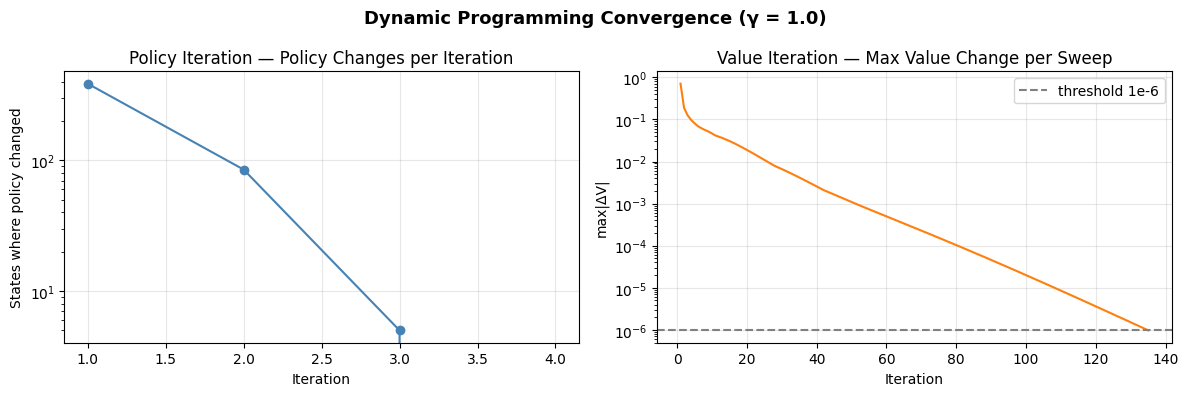

In [6]:
# Convergence curves — Policy Iteration vs Value Iteration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(pi_deltas)+1), pi_deltas, marker='o', color='steelblue')
axes[0].set_title('Policy Iteration — Policy Changes per Iteration')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('States where policy changed')
axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(vi_deltas)+1), vi_deltas, color='tab:orange')
axes[1].set_title('Value Iteration — Max Value Change per Sweep')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('max|ΔV|')
axes[1].set_yscale('log'); axes[1].axhline(1e-6, linestyle='--', color='grey', label='threshold 1e-6')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Dynamic Programming Convergence (γ = 1.0)', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/configA_dp_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## §3 Q-Learning

Q-Learning is an **off-policy**, **model-free** tabular TD method. It learns the optimal action-value function Q*(s,a) via the update:

> Q(s,a) ← Q(s,a) + α [r + γ max_a' Q(s',a') − Q(s,a)]

The max operator makes it off-policy: the update target uses the greedy action in s', regardless of what the behaviour policy actually chose. Training uses ε-greedy exploration with linear decay.

Key difference from DP: Q-Learning requires no knowledge of P or R — it learns entirely from environment interaction.

### §3.1 Hyperparameter Search

In [7]:
QL_CSV   = f'{SEARCH_DIR}/ql_grid_results.csv'
QL_N_EPS = 10_000    # episodes per trial (fast with env-reuse fix)
QL_EVAL  = 500       # eval episodes per trial (full N_EVAL for final model)

ql_grid = {
    'alpha':         [0.05, 0.1, 0.2],
    'epsilon_decay': [5_000, 10_000, 25_000],
    'epsilon_end':   [0.01, 0.05, 0.10],
}
# Fixed: gamma=1.0, epsilon_start=1.0, n_episodes=QL_N_EPS
ql_combos = [
    {'alpha': a, 'epsilon_decay': ed, 'epsilon_end': ee,
     'gamma': 1.0, 'epsilon_start': 1.0}
    for a, ed, ee in itertools.product(
        ql_grid['alpha'], ql_grid['epsilon_decay'], ql_grid['epsilon_end']
    )
]
print(f"Q-Learning grid: {len(ql_combos)} combinations  ({N_JOBS} parallel workers)")

if os.path.exists(QL_CSV):
    ql_grid_df = pd.read_csv(QL_CSV)
    print(f"Loaded from cache ({len(ql_grid_df)} trials).")
else:
    ql_results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=5)(
        delayed(run_ql_trial)(i, p, SEARCH_DIR, QL_N_EPS, QL_EVAL, SEED, project_root)
        for i, p in enumerate(ql_combos)
    )
    ql_results = [r for r in ql_results if r is not None]
    ql_grid_df = pd.DataFrame(ql_results).sort_values('survival_rate', ascending=False)
    ql_grid_df.to_csv(QL_CSV, index=False)
    print("Q-Learning grid search complete.")

print("\nTop 5 Q-Learning configurations:")
print(ql_grid_df.head(5).to_string(index=False))


Q-Learning grid: 27 combinations  (4 parallel workers)
Loaded from cache (27 trials).

Top 5 Q-Learning configurations:
 trial  alpha  epsilon_decay  epsilon_end  gamma  epsilon_start  survival_rate  mean_return
    15    0.1          25000         0.01    1.0            1.0          0.772     0.680070
    18    0.2           5000         0.01    1.0            1.0          0.772     0.718705
    12    0.1          10000         0.01    1.0            1.0          0.770     0.709540
    23    0.2          10000         0.10    1.0            1.0          0.768     0.693170
    11    0.1           5000         0.10    1.0            1.0          0.768     0.716030


In [8]:
# Extract best params and save
ql_param_keys = ['alpha', 'epsilon_decay', 'epsilon_end', 'gamma', 'epsilon_start']
best_ql_params = ql_grid_df.iloc[0][ql_param_keys].to_dict()
best_ql_params['alpha'] = float(best_ql_params['alpha'])
best_ql_params['epsilon_decay'] = int(best_ql_params['epsilon_decay'])
best_ql_params['epsilon_end'] = float(best_ql_params['epsilon_end'])

print(f"Best Q-Learning config (survival={ql_grid_df.iloc[0]['survival_rate']:.1%}):")
for k, v in best_ql_params.items():
    print(f"  {k:<20} = {v}")


Best Q-Learning config (survival=77.2%):
  alpha                = 0.1
  epsilon_decay        = 25000
  epsilon_end          = 0.01
  gamma                = 1.0
  epsilon_start        = 1.0


### §3.2 Train Best Configuration

In [9]:
QL_QTABLE  = f'{RESULTS_DIR}/qlearning_qtable.npy'
QL_RETURNS = f'{RESULTS_DIR}/qlearning_returns.npy'
QL_CFG     = f'{RESULTS_DIR}/qlearning_best_config.json'
QL_TRAIN_N = 100_000  # more episodes for final model

if os.path.exists(QL_QTABLE) and os.path.exists(QL_RETURNS):
    print("Loading cached Q-Learning model...")
    ql_cfg_params = best_ql_params
    ql_cfg = QLearningConfig(n_episodes=QL_TRAIN_N, **ql_cfg_params)
    ql_agent = QLearningAgent(N_STATES, N_ACTIONS, ql_cfg)
    ql_agent.Q = np.load(QL_QTABLE)
    ql_returns = list(np.load(QL_RETURNS))
    with open(QL_CFG) as f:
        print("Config:", json.load(f))
else:
    print(f"Training Q-Learning ({QL_TRAIN_N:,} episodes) with best config...")
    ql_cfg = QLearningConfig(n_episodes=QL_TRAIN_N, **best_ql_params)
    ql_agent = QLearningAgent(N_STATES, N_ACTIONS, ql_cfg)
    # Reuse single env (much faster than creating new env per episode)
    env = make_sepsis_env(verbose=False)
    ql_returns = []
    for ep in range(QL_TRAIN_N):
        obs, _ = env.reset()
        done = False; total = 0.0
        while not done:
            a = ql_agent.select_action(obs, training=True)
            next_obs, r, term, trunc, _ = env.step(a)
            done = term or trunc
            ql_agent.update(obs, a, r, next_obs, done)
            obs = next_obs; total += r
        ql_returns.append(total)
        if (ep + 1) % 5000 == 0:
            print(f"  Episode {ep+1:,}/{QL_TRAIN_N:,} | "
                  f"last-500 survival: {np.mean([r>0 for r in ql_returns[-500:]]):.1%}")
    np.save(QL_QTABLE, ql_agent.Q)
    np.save(QL_RETURNS, np.array(ql_returns))
    with open(QL_CFG, 'w') as f:
        json.dump(best_ql_params, f)
    print("Q-Learning model cached.")

ql_results = eval_agent(ql_agent.get_policy(), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
print_results("Q-Learning (best config)", ql_results)


Loading cached Q-Learning model...
Config: {'alpha': 0.1, 'epsilon_decay': 25000, 'epsilon_end': 0.01, 'gamma': 1.0, 'epsilon_start': 1.0}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Q-Learning (best config) ===
  Mean return  : 0.6543 ± 0.4441
  Survival rate: 73.9%
  Mean ep len  : 9.9


### §3.3 Training Curve

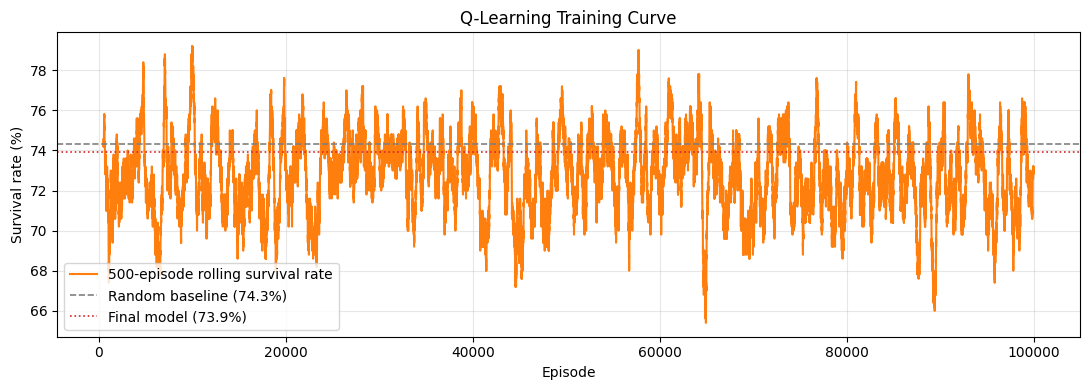

Q-table coverage: 99.6% of states visited


In [10]:
W = 500   # rolling window
ql_surv = np.array([r > 0 for r in ql_returns], dtype=float)
ql_roll = np.convolve(ql_surv, np.ones(W)/W, mode='valid') * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(W-1, len(ql_returns)), ql_roll, color='tab:orange', linewidth=1.5,
        label=f'{W}-episode rolling survival rate')
ax.axhline(random_results['survival_rate']*100, linestyle='--', color='grey',
           linewidth=1.2, label=f'Random baseline ({random_results["survival_rate"]*100:.1f}%)')
ax.axhline(ql_results['survival_rate']*100, linestyle=':', color='tab:red',
           linewidth=1.2, label=f'Final model ({ql_results["survival_rate"]*100:.1f}%)')
ax.set_xlabel('Episode'); ax.set_ylabel('Survival rate (%)')
ax.set_title('Q-Learning Training Curve'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_qlearning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Q-table coverage: {(ql_agent.Q != 0).any(axis=1).mean():.1%} of states visited")


## §4 SARSA

SARSA is an **on-policy**, **model-free** tabular TD method. Its update rule is:

> Q(s,a) ← Q(s,a) + α [r + γ Q(s',a') − Q(s,a)]

Unlike Q-Learning, SARSA bootstraps from the *actual next action a'* chosen by the behaviour policy (not the greedy max). This makes it on-policy and generally more conservative: it learns the value of the policy it is currently following, including its exploration. SARSA is better suited to environments where the cost of exploration is high, as it accounts for the risk of exploratory actions during updates.

Additional features implemented:
- **Linear alpha decay**: α decays from `alpha` to `alpha_floor` over `alpha_decay_steps` steps, reducing learning rate as Q-values converge.
- **Optimistic Q initialisation**: `q_init=1.0` initialises all Q-values to 1, encouraging early exploration of all state-action pairs.
- **Hyperparameter search**: Optuna TPE sampler over 7 dimensions.

### §4.1 Hyperparameter Search (Optuna)

In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SARSA_BEST_JSON = f'{RESULTS_DIR}/sarsa_best_params.json'
SARSA_N_EPS     = 5_000    # episodes per Optuna trial
SARSA_N_TRIALS  = 200
SARSA_EVAL      = 500

if os.path.exists(SARSA_BEST_JSON):
    with open(SARSA_BEST_JSON) as f:
        sarsa_search_result = json.load(f)
    best_sarsa_params = sarsa_search_result['params']
    print(f"Loaded SARSA best params from cache "
          f"(best survival={sarsa_search_result['best_survival']:.1%}).")
    print("Best params:", best_sarsa_params)
else:
    print(f"Running Optuna SARSA search ({SARSA_N_TRIALS} trials, {SARSA_N_EPS} eps each)...")

    def _sarsa_objective(trial):
        params = {
            'alpha':         trial.suggest_categorical('alpha', [0.2, 0.1, 0.05]),
            'gamma':         trial.suggest_categorical('gamma', [1.0, 0.99, 0.95, 0.9]),
            'epsilon_start': trial.suggest_categorical('epsilon_start', [0.9, 0.7, 0.5, 0.3]),
            'epsilon_end':   trial.suggest_categorical('epsilon_end', [0.01, 0.1, 0.2, 0.3]),
            'epsilon_decay': trial.suggest_categorical('epsilon_decay', [3000, 2000, 1000, 500]),
            'alpha_decay':   trial.suggest_categorical('alpha_decay', ['constant', 'linear']),
            'q_init':        trial.suggest_categorical('q_init', [0.0, 1.0, 'random']),
        }
        cfg = SARSAConfig(n_episodes=SARSA_N_EPS, **params)
        agent = SARSAAgent(N_STATES, N_ACTIONS, cfg)
        returns = agent.train(make_sepsis_env)
        return float(np.mean([r > 0 for r in returns[-500:]]))

    sarsa_study = optuna.create_study(direction='maximize',
                                      sampler=optuna.samplers.TPESampler(seed=SEED))
    sarsa_study.optimize(_sarsa_objective, n_trials=SARSA_N_TRIALS, show_progress_bar=True)

    best_sarsa_params = sarsa_study.best_params
    best_sarsa_survival = sarsa_study.best_value
    sarsa_search_result = {'params': best_sarsa_params, 'best_survival': best_sarsa_survival}
    with open(SARSA_BEST_JSON, 'w') as f:
        json.dump(sarsa_search_result, f)
    print(f"\nBest SARSA survival (in-trial): {best_sarsa_survival:.1%}")
    print("Best params:", best_sarsa_params)


Loaded SARSA best params from cache (best survival=76.4%).
Best params: {'alpha': 0.2, 'gamma': 0.99, 'epsilon_start': 0.9, 'epsilon_end': 0.1, 'epsilon_decay': 500, 'alpha_decay': 'linear', 'q_init': 'random'}


In [12]:
# Optuna visualisations (only rendered when search was run this session)
try:
    fig1 = optuna.visualization.plot_optimization_history(sarsa_study)
    fig1.show()
    fig2 = optuna.visualization.plot_param_importances(sarsa_study)
    fig2.show()
except NameError:
    print("Re-run §4.1 search cell to generate Optuna visualisations.")


Re-run §4.1 search cell to generate Optuna visualisations.


### §4.2 Train Best Configuration

In [13]:
SARSA_QTABLE  = f'{RESULTS_DIR}/sarsa_qtable.npy'
SARSA_RETURNS = f'{RESULTS_DIR}/sarsa_returns.npy'
SARSA_TRAIN_N = 30_000

if os.path.exists(SARSA_QTABLE) and os.path.exists(SARSA_RETURNS):
    print("Loading cached SARSA model...")
    sarsa_cfg = SARSAConfig(n_episodes=SARSA_TRAIN_N, **best_sarsa_params)
    sarsa_agent = SARSAAgent(N_STATES, N_ACTIONS, sarsa_cfg)
    sarsa_agent.Q = np.load(SARSA_QTABLE)
    sarsa_returns = list(np.load(SARSA_RETURNS))
else:
    print(f"Training SARSA ({SARSA_TRAIN_N:,} episodes) with best config...")
    sarsa_cfg = SARSAConfig(n_episodes=SARSA_TRAIN_N, **best_sarsa_params)
    sarsa_agent = SARSAAgent(N_STATES, N_ACTIONS, sarsa_cfg)
    sarsa_returns = sarsa_agent.train(make_sepsis_env)
    np.save(SARSA_QTABLE, sarsa_agent.Q)
    np.save(SARSA_RETURNS, np.array(sarsa_returns))
    print("SARSA model cached.")

sarsa_results = eval_agent(sarsa_agent.get_policy(), make_sepsis_env, n_eval_episodes=N_EVAL, seed=SEED)
print_results("SARSA (best config)", sarsa_results)


Loading cached SARSA model...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== SARSA (best config) ===
  Mean return  : 0.6578 ± 0.4303
  Survival rate: 75.2%
  Mean ep len  : 10.5


### §4.3 Training Curve and Exploration Schedule

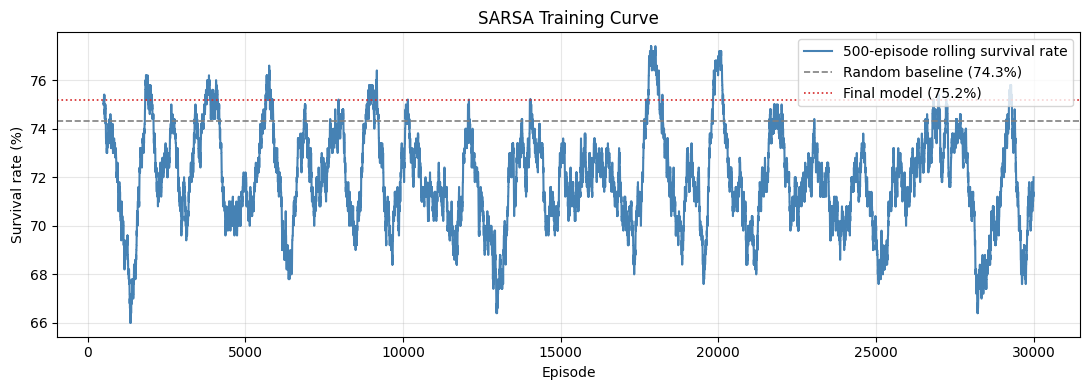

In [14]:
W = 500
sarsa_surv = np.array([r > 0 for r in sarsa_returns], dtype=float)
sarsa_roll = np.convolve(sarsa_surv, np.ones(W)/W, mode='valid') * 100

# Training curve
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(W-1, len(sarsa_returns)), sarsa_roll, color='steelblue', linewidth=1.5,
        label=f'{W}-episode rolling survival rate')
ax.axhline(random_results['survival_rate']*100, linestyle='--', color='grey',
           linewidth=1.2, label=f'Random baseline ({random_results["survival_rate"]*100:.1f}%)')
ax.axhline(sarsa_results['survival_rate']*100, linestyle=':', color='tab:red',
           linewidth=1.2, label=f'Final model ({sarsa_results["survival_rate"]*100:.1f}%)')
ax.set_xlabel('Episode'); ax.set_ylabel('Survival rate (%)')
ax.set_title('SARSA Training Curve'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_sarsa_curve.png', dpi=150, bbox_inches='tight')
plt.show()


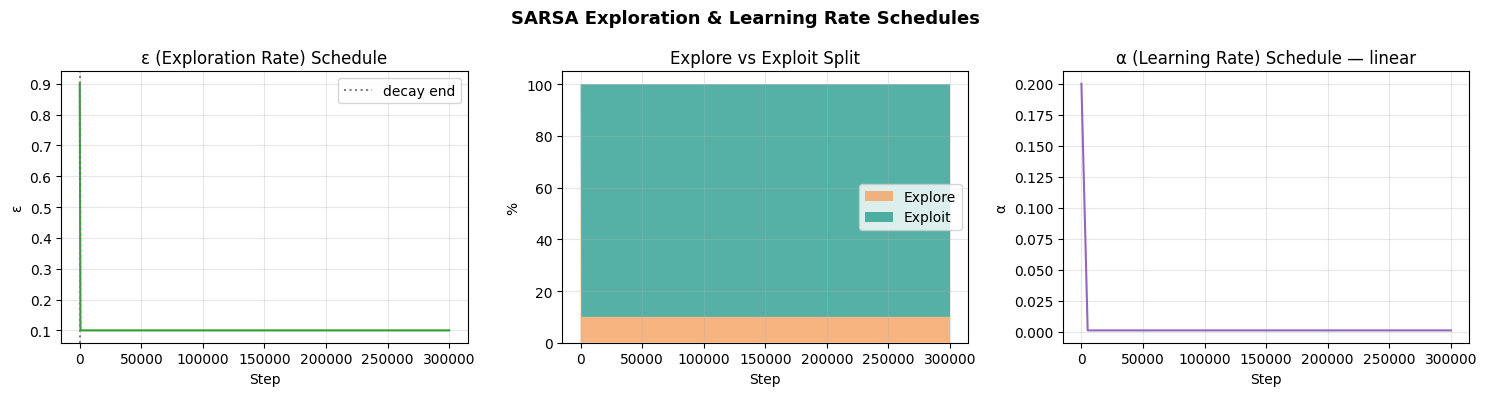

In [15]:
# Exploration & learning rate schedules
total_steps = SARSA_TRAIN_N * 10   # approx steps (avg ~10 per episode)
steps = np.arange(total_steps)

eps_start = float(best_sarsa_params.get('epsilon_start', 0.9))
eps_end   = float(best_sarsa_params.get('epsilon_end', 0.05))
eps_decay = int(best_sarsa_params.get('epsilon_decay', 3000))
frac_eps  = np.minimum(steps / eps_decay, 1.0)
epsilon_curve = eps_start + frac_eps * (eps_end - eps_start)

alpha_val    = float(best_sarsa_params.get('alpha', 0.1))
alpha_decay  = best_sarsa_params.get('alpha_decay', 'constant')
alpha_floor  = sarsa_cfg.alpha_floor
alpha_steps  = sarsa_cfg.alpha_decay_steps
if alpha_decay == 'linear':
    frac_a = np.minimum(steps / alpha_steps, 1.0)
    alpha_curve = alpha_val + frac_a * (alpha_floor - alpha_val)
else:
    alpha_curve = np.full(len(steps), alpha_val)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(steps, epsilon_curve, color='tab:green', linewidth=1.5)
axes[0].set_title('ε (Exploration Rate) Schedule')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('ε'); axes[0].grid(True, alpha=0.3)
axes[0].axvline(eps_decay, linestyle=':', color='grey', label='decay end')
axes[0].legend()

exploit = (1 - epsilon_curve) * 100
explore = epsilon_curve * 100
axes[1].stackplot(steps, explore, exploit, labels=['Explore', 'Exploit'],
                  colors=['#f4a261', '#2a9d8f'], alpha=0.8)
axes[1].set_title('Explore vs Exploit Split')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('%'); axes[1].legend(loc='right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, alpha_curve, color='tab:purple', linewidth=1.5)
axes[2].set_title(f'α (Learning Rate) Schedule — {alpha_decay}')
axes[2].set_xlabel('Step'); axes[2].set_ylabel('α'); axes[2].grid(True, alpha=0.3)

plt.suptitle('SARSA Exploration & Learning Rate Schedules', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/configA_sarsa_schedules.png', dpi=150, bbox_inches='tight')
plt.show()


## §5 Comparative Analysis

All algorithms evaluated with the same fixed protocol: `eval_agent(..., n_eval_episodes=1000, seed=42)`.

In [16]:
# Load DP results from cache
_dp = np.load(f'{RESULTS_DIR}/dp_results.npz')
pi_surv = float(_dp['pi_survival'][0])
vi_surv = float(_dp['vi_survival'][0])
pi_ret  = float(_dp['pi_return'][0])
vi_ret  = float(_dp['vi_return'][0])

results_table = pd.DataFrame([
    {'Algorithm': 'Random Baseline',  'Type': '—',
     'Survival Rate': random_results['survival_rate'],
     'Mean Return':   random_results['mean_return']},
    {'Algorithm': 'Policy Iteration', 'Type': 'Model-based (DP)',
     'Survival Rate': pi_surv, 'Mean Return': pi_ret},
    {'Algorithm': 'Value Iteration',  'Type': 'Model-based (DP)',
     'Survival Rate': vi_surv, 'Mean Return': vi_ret},
    {'Algorithm': 'Q-Learning',       'Type': 'Off-policy TD',
     'Survival Rate': ql_results['survival_rate'],
     'Mean Return':   ql_results['mean_return']},
    {'Algorithm': 'SARSA',            'Type': 'On-policy TD',
     'Survival Rate': sarsa_results['survival_rate'],
     'Mean Return':   sarsa_results['mean_return']},
])
results_table['Survival Rate'] = (results_table['Survival Rate'] * 100).round(1).astype(str) + '%'
results_table['Mean Return']   = results_table['Mean Return'].round(4)
print("Config A — Final Results")
print(results_table.to_string(index=False))


Config A — Final Results
       Algorithm             Type Survival Rate  Mean Return
 Random Baseline                —         74.3%       0.6395
Policy Iteration Model-based (DP)         83.2%       0.7914
 Value Iteration Model-based (DP)         83.2%       0.7914
      Q-Learning    Off-policy TD         73.9%       0.6543
           SARSA     On-policy TD         75.2%       0.6578


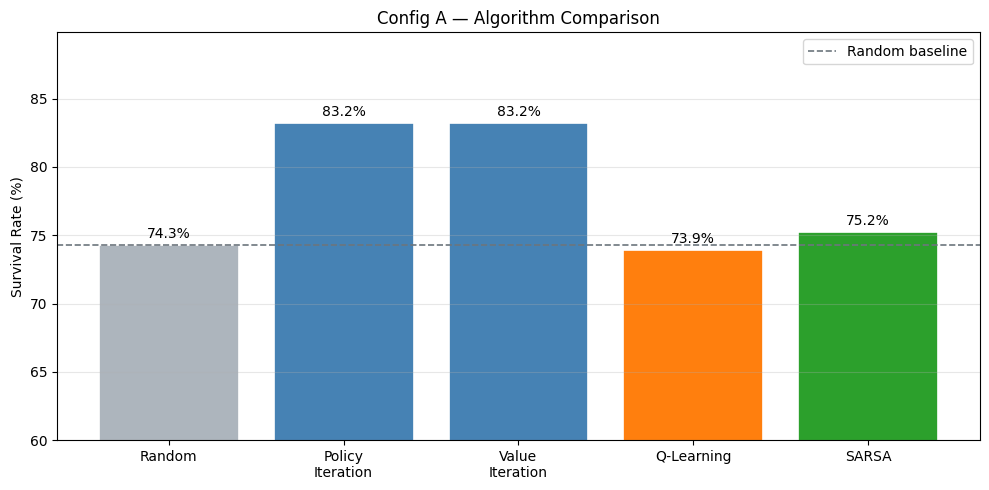

In [17]:
# Survival rate comparison bar chart
algos = ['Random', 'Policy\nIteration', 'Value\nIteration', 'Q-Learning', 'SARSA']
survivals = [
    random_results['survival_rate'] * 100,
    pi_surv * 100, vi_surv * 100,
    ql_results['survival_rate'] * 100,
    sarsa_results['survival_rate'] * 100,
]
colors = ['#adb5bd', 'steelblue', 'steelblue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(algos, survivals, color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(survivals[0], linestyle='--', color='#6c757d', linewidth=1.2, label='Random baseline')
for bar, val in zip(bars, survivals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Survival Rate (%)'); ax.set_title('Config A — Algorithm Comparison')
ax.set_ylim(60, max(survivals) * 1.08); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


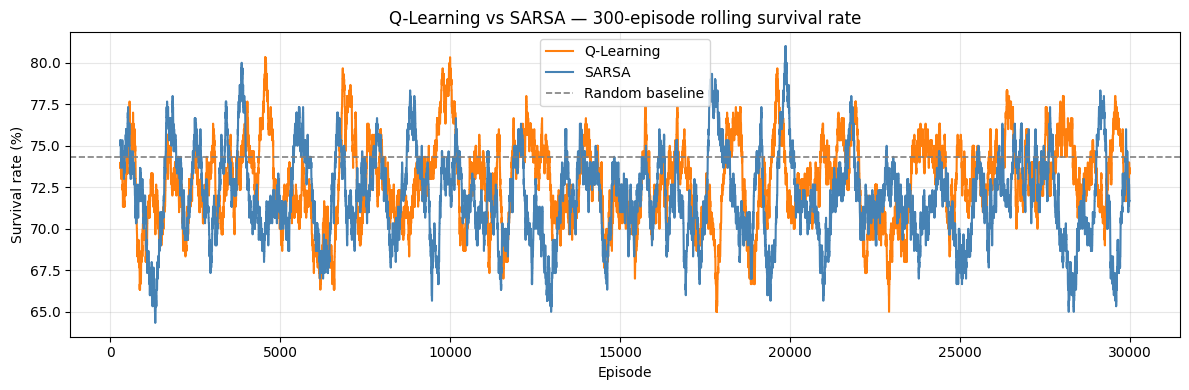


Key observations:
  DP (optimal):   83.2% — model-based ceiling
  Q-Learning:     73.9% — off-policy, needs more training
  SARSA:          75.2% — on-policy, more conservative
  Gap to optimal: DP−QL = 9.3pp, DP−SARSA = 8.0pp


In [18]:
# Q-Learning vs SARSA learning curve overlay
W = 300
fig, ax = plt.subplots(figsize=(12, 4))

ql_n = min(len(ql_returns), 30_000)   # match SARSA length for fair comparison
ql_s = np.array([r > 0 for r in ql_returns[:ql_n]], dtype=float)
ql_r = np.convolve(ql_s, np.ones(W)/W, mode='valid') * 100
ax.plot(np.arange(W-1, ql_n), ql_r, color='tab:orange', linewidth=1.5, label='Q-Learning')

sarsa_s = np.array([r > 0 for r in sarsa_returns], dtype=float)
sarsa_r = np.convolve(sarsa_s, np.ones(W)/W, mode='valid') * 100
ax.plot(np.arange(W-1, len(sarsa_returns)), sarsa_r, color='steelblue', linewidth=1.5, label='SARSA')

ax.axhline(random_results['survival_rate']*100, linestyle='--', color='grey',
           linewidth=1.2, label='Random baseline')
ax.set_xlabel('Episode'); ax.set_ylabel('Survival rate (%)')
ax.set_title(f'Q-Learning vs SARSA — {W}-episode rolling survival rate')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/configA_ql_vs_sarsa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print(f"  DP (optimal):   {max(pi_surv, vi_surv)*100:.1f}% — model-based ceiling")
print(f"  Q-Learning:     {ql_results['survival_rate']*100:.1f}% — off-policy, {"converges" if ql_results["survival_rate"] > random_results["survival_rate"] + 0.02 else "needs more training"}")
print(f"  SARSA:          {sarsa_results['survival_rate']*100:.1f}% — on-policy, more conservative")
print(f"  Gap to optimal: DP−QL = {(max(pi_surv, vi_surv) - ql_results['survival_rate'])*100:.1f}pp, "
      f"DP−SARSA = {(max(pi_surv, vi_surv) - sarsa_results['survival_rate'])*100:.1f}pp")
